Notebook: Notebook 3 – Regression Modelling & Ensemble Learning
Date: 24/03/2026


In [16]:
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn import tree
from matplotlib import pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import RocCurveDisplay

print("All libraries imported successfully.")

All libraries imported successfully.


In [18]:
# Load classification dataset (same as Notebook 2)
df_loan_status = pd.read_csv('/content/loan_approval__data.csv')

# The inputs are all the variables in the data assigned to X except the target
X = df_loan_status.drop(['loan_approval_status'], axis=1)

# The target output is assigned to y
y = df_loan_status['loan_approval_status']

# Split dataset into train and test — same random_state=14 and stratify=y as Notebook 2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=14, stratify=y)

# Scale input variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X1_train = scaler.fit_transform(X_train)
X1_test  = scaler.transform(X_test)

print("Data loaded and split. Train:", X_train.shape, "| Test:", X_test.shape)

Data loaded and split. Train: (46916, 10) | Test: (11729, 10)


Classification report for NB
              precision    recall  f1-score   support

           0       0.93      0.89      0.91     10059
           1       0.49      0.62      0.55      1670

    accuracy                           0.86     11729
   macro avg       0.71      0.76      0.73     11729
weighted avg       0.87      0.86      0.86     11729

confusion_matrix for NB


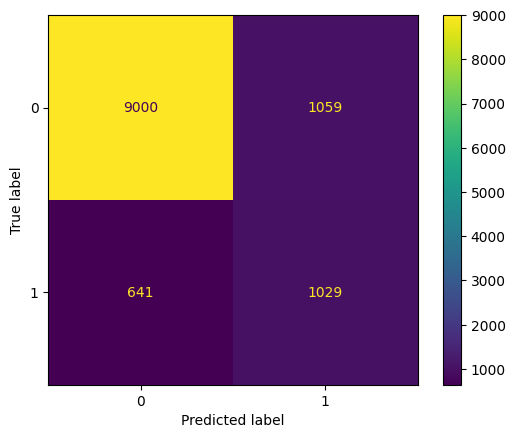

In [19]:
# import the NB algorithm, build the NB model then test it by predicting on the test data
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb = nb.fit(X1_train, y_train)
y_pred_nb = nb.predict(X1_test)

# Evaluate NB model by generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for NB")
print(classification_report(y_test, y_pred_nb))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for NB")
nb_cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=nb_cm, display_labels=nb.classes_)
disp.plot()

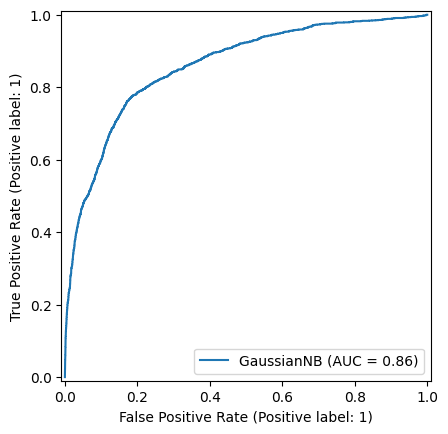

In [20]:
# ROC Curve for NB base learner
from sklearn.metrics import RocCurveDisplay
nb_roc = RocCurveDisplay.from_estimator(nb, X1_test, y_test)

Classification report for LR
              precision    recall  f1-score   support

           0       0.91      0.98      0.94     10059
           1       0.73      0.38      0.50      1670

    accuracy                           0.89     11729
   macro avg       0.82      0.68      0.72     11729
weighted avg       0.88      0.89      0.88     11729

confusion_matrix for lr


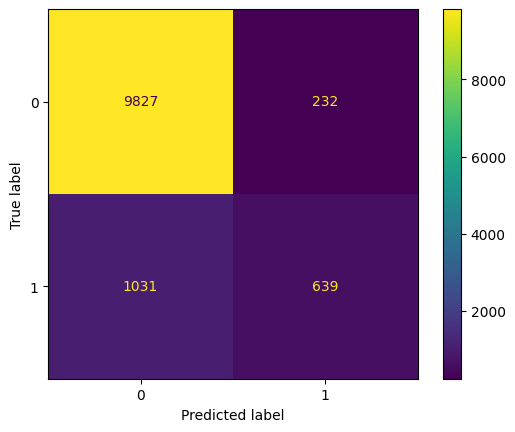

In [21]:
# import the LR algorithm, build the LR model then test it by predicting on the test data
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr = lr.fit(X1_train, y_train)
y_pred_lr = lr.predict(X1_test)

# Evaluate LR model by generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for LR")
print(classification_report(y_test, y_pred_lr))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for lr")
lr_cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=lr.classes_)
disp.plot()

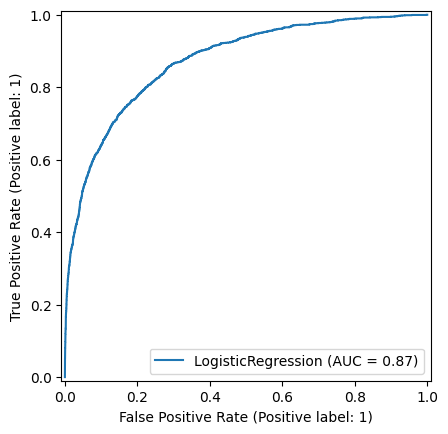

In [22]:
from sklearn.metrics import RocCurveDisplay
Logreg_roc = RocCurveDisplay.from_estimator(lr, X1_test, y_test)

Classification report for Ensembler
              precision    recall  f1-score   support

           0       0.93      0.94      0.93     10059
           1       0.60      0.56      0.58      1670

    accuracy                           0.88     11729
   macro avg       0.76      0.75      0.76     11729
weighted avg       0.88      0.88      0.88     11729

confusion_matrix for ensemble learner


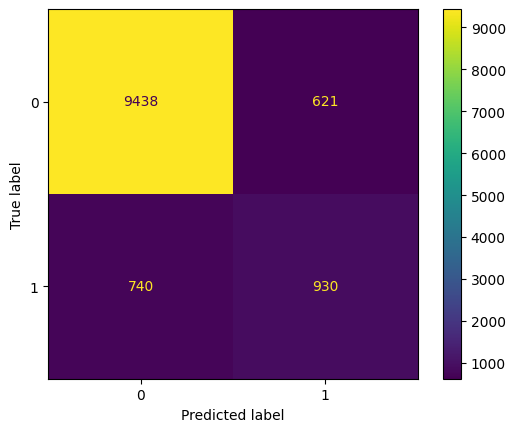

In [23]:
# initiate a new ensemble model
from sklearn.ensemble import VotingClassifier

# create a dictionary of our base learner models
base_learners = [('NB', nb), ('LR', lr)]

# create our voting classifier, inputting our models
ensemble_learner = VotingClassifier(base_learners, voting='soft')

# fit model to training data
ensemble_learner = ensemble_learner.fit(X1_train, y_train)
y_pred_ensembler = ensemble_learner.predict(X1_test)

# Evaluate your ensemble model by generating the classification report and the confusion matrix
from sklearn.metrics import classification_report
print("Classification report for Ensembler")
print(classification_report(y_test, y_pred_ensembler))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

print("confusion_matrix for ensemble learner")
ensemble_learner_cm = confusion_matrix(y_test, y_pred_ensembler)
disp = ConfusionMatrixDisplay(confusion_matrix=ensemble_learner_cm, display_labels=ensemble_learner.classes_)
disp.plot()

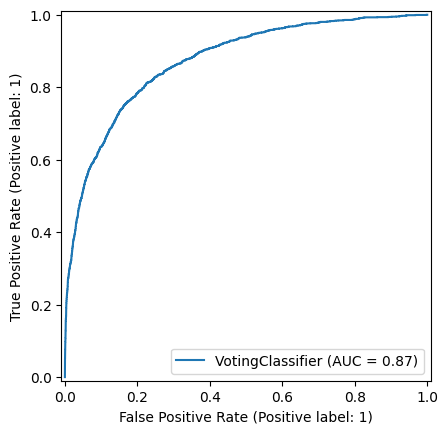

In [24]:
# ROC curve for ensemble learner
from sklearn.metrics import RocCurveDisplay
ensemble_roc = RocCurveDisplay.from_estimator(ensemble_learner, X1_test, y_test)

In [25]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
print("Ensemble vs Base Learners — Performance Comparison (Rejected class=1):")
print("-" * 80)
for name, yp, yprob in [
    ("NB",       y_pred_nb,       nb.predict_proba(X1_test)[:,1]),
    ("LR",       y_pred_lr,       lr.predict_proba(X1_test)[:,1]),
    ("Ensemble", y_pred_ensembler, ensemble_learner.predict_proba(X1_test)[:,1]),
]:
    acc = round(accuracy_score(y_test, yp),4)
    rec = round(recall_score(y_test, yp, pos_label=1),4)
    prc = round(precision_score(y_test, yp, pos_label=1),4)
    f1  = round(f1_score(y_test, yp, pos_label=1),4)
    auc = round(roc_auc_score(y_test, yprob),4)
    print(f"{name:>12}: Acc={acc}  Rec(1)={rec}  Prec(1)={prc}  F1(1)={f1}  AUC={auc}")

Ensemble vs Base Learners — Performance Comparison (Rejected class=1):
--------------------------------------------------------------------------------
          NB: Acc=0.8551  Rec(1)=0.6162  Prec(1)=0.4928  F1(1)=0.5476  AUC=0.8586
          LR: Acc=0.8923  Rec(1)=0.3826  Prec(1)=0.7336  F1(1)=0.503  AUC=0.8726
    Ensemble: Acc=0.884  Rec(1)=0.5569  Prec(1)=0.5996  F1(1)=0.5775  AUC=0.8727


In [27]:
# Load classification dataset file loan_max_amount_data.csv for regression modelling
df_loan_max = pd.read_csv('/content/loan_max_amount_data.csv')
df_loan_max.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
0,40.0,182004,3,3,1,35000,8.00,0.19,0,11,35000
1,40.0,90000,0,3,2,35000,12.42,0.39,0,14,35000
2,40.0,131004,0,9,5,30000,7.90,0.23,0,13,30000
3,40.0,150000,0,9,0,25000,11.89,0.17,0,11,25000
4,40.0,132000,0,3,2,25000,16.82,0.22,0,17,25000


In [28]:
X = df_loan_max.drop(['max_allowed_loan'], axis=1)
y = df_loan_max['max_allowed_loan']

print("Regression dataset shape:", df_loan_max.shape)
print("Input feature names:", list(X.columns))
print("Target: max_allowed_loan")

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

Regression dataset shape: (50292, 11)
Input feature names: ['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length']
Target: max_allowed_loan
X_train: (40233, 10) | X_test: (10059, 10)


In [29]:
regressor = DecisionTreeRegressor()
regressor.fit(X_train, y_train)

# To make predictions on the test set, use the predict method:
y_pred = regressor.predict(X_test)

# Display the full tree depth
print("The full Regression Decision Tree Levels:", regressor.tree_.max_depth)

The full Regression Decision Tree Levels: 25


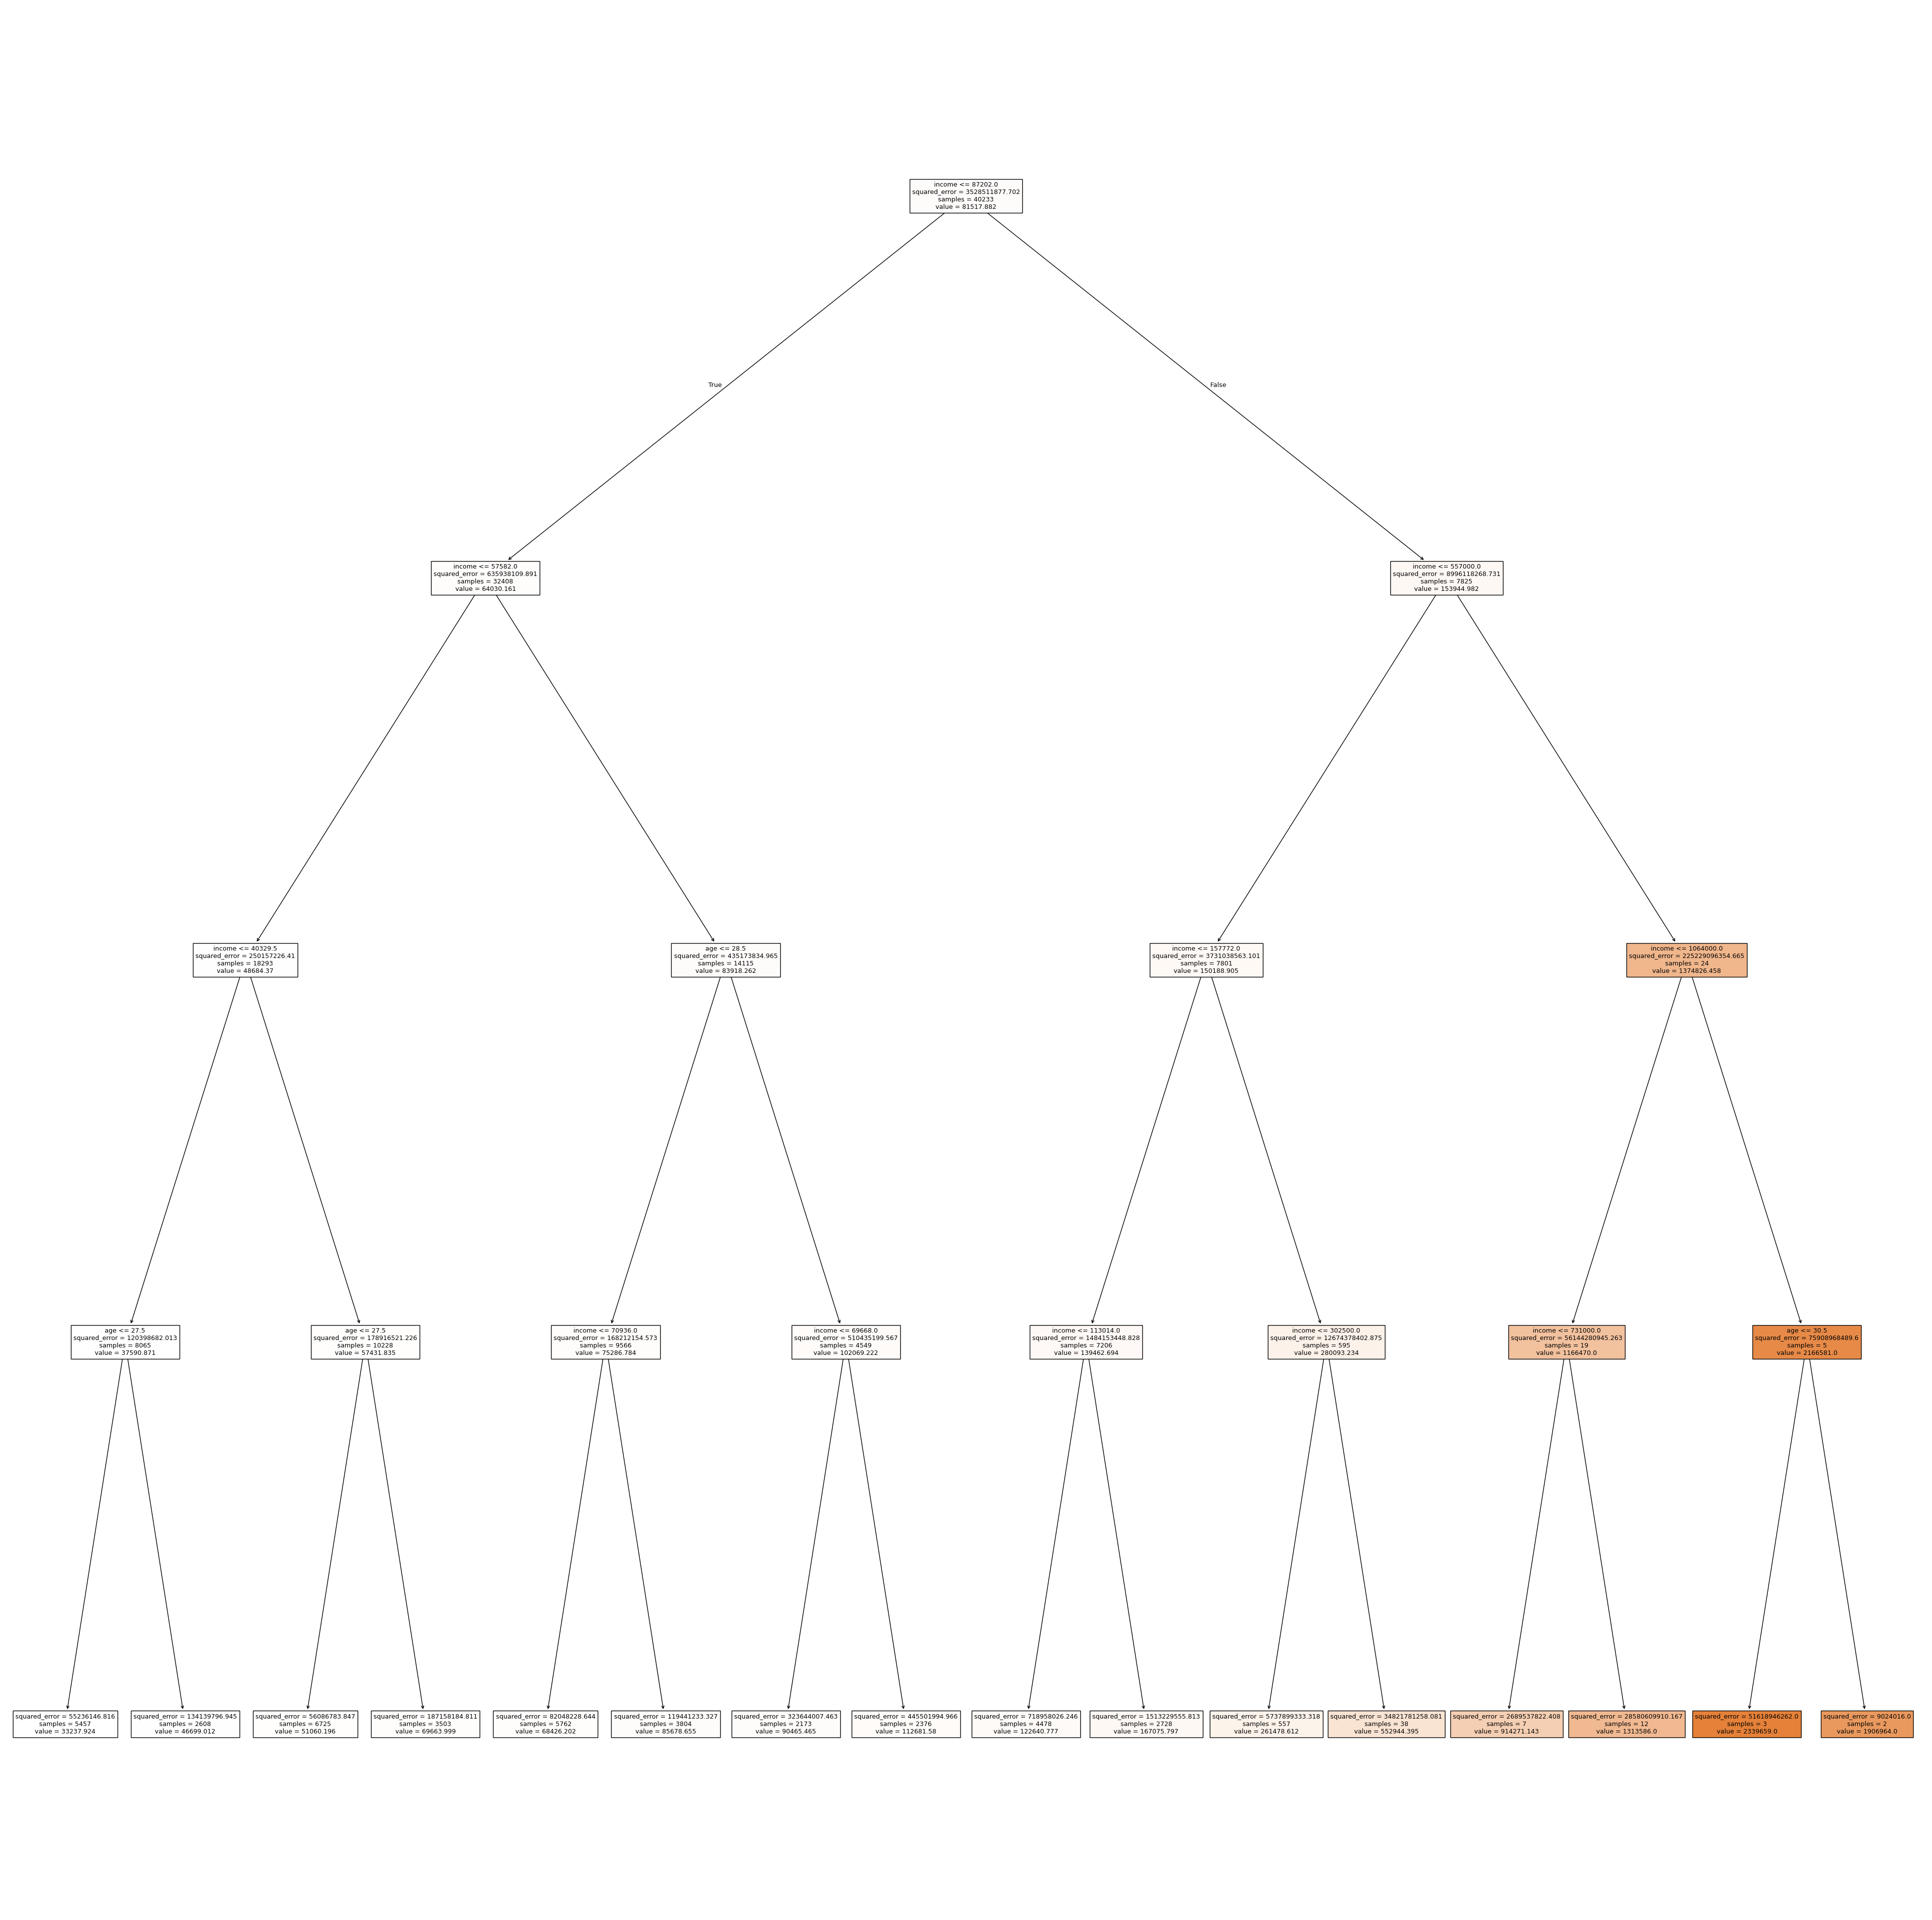

DT-2 (max_depth=4) depth: 4


In [30]:
pruned_regressor = DecisionTreeRegressor(max_depth=4)
pruned_regressor.fit(X_train, y_train)

# To make predictions on the test set, use the predict method:
y_pred_pruned = pruned_regressor.predict(X_test)

# Plot the regression DT
pruned_Tree_model = plt.figure(figsize=(50, 50))
pruned_Tree_model_Graph = tree.plot_tree(pruned_regressor, feature_names=list(X_train.columns), filled=True)

# To save the DT graph as a png image
pruned_Tree_model.savefig("pruned_reg_decision_tree.png")
plt.show()
print("DT-2 (max_depth=4) depth:", pruned_regressor.tree_.max_depth)

In [31]:
DT1_figure = plt.figure(figsize=(200, 80))
tree.plot_tree(regressor, feature_names=list(X_train.columns), filled=True, max_depth=3)
DT1_figure.savefig("fully_grown_reg_decision_tree.png")
plt.show()
print("DT-1 (Fully Grown) depth:", regressor.tree_.max_depth)

DT-1 (Fully Grown) depth: 25


In [32]:
# Calculating the regression metrics for the fully grown regression decision Tree
print("=== DT-1 (Fully Grown) ===")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('R2:', metrics.r2_score(y_test, y_pred))

=== DT-1 (Fully Grown) ===
Mean Absolute Error: 1216.4408986976837
Mean Squared Error: 52119797.17536534
Root Mean Squared Error: 7219.404211939192
R2: 0.9812239268101169


In [33]:
# Calculating the regression metrics for the pruned regression decision Tree
print("=== DT-2 (Pruned, max_depth=4) ===")
print('Mean Absolute Error:', metrics.mean_absolute_error(y_test, y_pred_pruned))
print('Mean Squared Error:', metrics.mean_squared_error(y_test, y_pred_pruned))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_test, y_pred_pruned)))
print('R2:', metrics.r2_score(y_test, y_pred_pruned))

=== DT-2 (Pruned, max_depth=4) ===
Mean Absolute Error: 11801.054777073194
Mean Squared Error: 374722938.7727772
Root Mean Squared Error: 19357.761719082533
R2: 0.8650066633864176


In [34]:
import pandas as pd
client_60256 = pd.DataFrame({
    'age':                    [56.0],
    'income':                 [57000],
    'home_ownership':         [3],    # RENT = 3
    'emplyment_length':       [15],
    'loan_intent':            [3],    # MEDICAL = 3
    'loan_amount':            [25700],
    'loan_interest_rate':     [23.0],
    'loan_income_ratio':      [0.10], # 10%
    'payment_default_on_file':[0],    # N = 0
    'credit_history_length':  [35]
})

print("Client 60256 attribute values:")
print(client_60256.T)
print()

# To make predictions using the predict method
y_pred_client_dt1 = regressor.predict(client_60256)
y_pred_client_dt2 = pruned_regressor.predict(client_60256)

print(f"DT-1 (Fully Grown) Predicted Maximum Loan Amount for Client 60256: £{y_pred_client_dt1[0]:,.2f}")
print(f"DT-2 (Pruned)      Predicted Maximum Loan Amount for Client 60256: £{y_pred_client_dt2[0]:,.2f}")

Client 60256 attribute values:
                               0
age                         56.0
income                   57000.0
home_ownership               3.0
emplyment_length            15.0
loan_intent                  3.0
loan_amount              25700.0
loan_interest_rate          23.0
loan_income_ratio            0.1
payment_default_on_file      0.0
credit_history_length       35.0

DT-1 (Fully Grown) Predicted Maximum Loan Amount for Client 60256: £80,501.00
DT-2 (Pruned)      Predicted Maximum Loan Amount for Client 60256: £69,664.00


In [35]:
# Trace DT-2 decision path for Client 60256 to interpret the prediction
from sklearn.tree import _tree

node_indicator = pruned_regressor.decision_path(client_60256)
leaf_id = pruned_regressor.apply(client_60256)
t = pruned_regressor.tree_
feat_names = list(X_train.columns)
sample_id = 0
node_ids = node_indicator.indices[node_indicator.indptr[sample_id]:node_indicator.indptr[sample_id+1]]

print("Decision path for Client 60256 through DT-2 (max_depth=4):")
print("="*70)
for node_id in node_ids:
    if t.children_left[node_id] == _tree.TREE_LEAF:
        n_samples = int(t.n_node_samples[node_id])
        leaf_val = float(t.value[node_id][0][0])
        print(f"  LEAF Node {node_id}: n_samples={n_samples:,}  predicted_max_allowed_loan=£{leaf_val:,.2f}")
    else:
        feat = feat_names[t.feature[node_id]]
        thr  = round(t.threshold[node_id], 2)
        cval = float(client_60256.iloc[0][feat])
        dirn = 'LEFT (<= threshold)' if cval <= thr else 'RIGHT (> threshold)'
        print(f"  Node {node_id}: {feat} <= {thr}?  client_value={cval}  -> {dirn}")
print()
print(f"Final prediction (DT-2): £{y_pred_client_dt2[0]:,.2f}")
print("This is the mean max_allowed_loan of all approved training clients at the leaf node above.")

Decision path for Client 60256 through DT-2 (max_depth=4):
  Node 0: income <= 87202.0?  client_value=57000.0  -> LEFT (<= threshold)
  Node 1: income <= 57582.0?  client_value=57000.0  -> LEFT (<= threshold)
  Node 2: income <= 40329.5?  client_value=57000.0  -> RIGHT (> threshold)
  Node 6: age <= 27.5?  client_value=56.0  -> RIGHT (> threshold)
  LEAF Node 8: n_samples=3,503  predicted_max_allowed_loan=£69,664.00

Final prediction (DT-2): £69,664.00
This is the mean max_allowed_loan of all approved training clients at the leaf node above.
